In [2]:
from sogaPreprocessor import *
from producecfg import *
from libSOGA import *
from scipy.stats import multivariate_normal
import signal
import torch
from torch.distributions.multivariate_normal import MultivariateNormal
torch.set_default_dtype(torch.float64)
from programs import *  
from data_generating_process import *
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
def compute_likelihood(output_dist, data_var_list, data):
    """ computes the likelihood of output_dist with respect to variables data_var_list sampled in data """

    
    data = torch.tensor(data)
    likelihood = 0
    # extract indexes of the variables in the data
    try:
        data_var_index = [output_dist.var_list.index(element) for element in data_var_list ]
    except ValueError:  # if the program doesn't have all the variables we are using for the likelihood
            return torch.tensor(-np.inf)
    except:
            raise
    for k in range(output_dist.gm.n_comp()):
        # extract the covariance matrix only for the variables in the data
        sigma = output_dist.gm.sigma[k][data_var_index][:, data_var_index]
        # first I consider the mu only for variables in the data
        mu = torch.tensor(output_dist.gm.mu[k][data_var_index])
        # selects indices of delta (discrete) variables and non-delta (continuous) variables
        deltas = np.where(np.diag(sigma) == 0)[0]
        not_deltas = np.where(np.diag(sigma) != 0)[0]
        # saves means of delta and non-delta variables and covariance matrix of non-delta
        mu_delta = mu[deltas]
        mu_not_delta = mu[not_deltas]
        sigma_not_delta = torch.tensor(sigma[not_deltas][:, not_deltas])
        # computes pdf of non-delta variables 
        if len(mu_not_delta) >= 1:  # if there is at least one continuous variable
            continuous_pdf = output_dist.gm.pi[k]*MultivariateNormal(mu_not_delta, sigma_not_delta).log_prob(data[:,not_deltas]).exp()
        else:
            continuous_pdf = output_dist.gm.pi[k]*torch.ones(len(data))
        # computes pmf of delta variables
        if len(mu_delta) >= 1:   # if there is at least one discrete variable
            discrete_pmf = torch.all((mu_delta == data[:, deltas]),dim=1)
        else:
            discrete_pmf = torch.ones(len(data))
        #except ValueError:  # if the covariance matrix is singular
        #    return torch.tensor(-np.inf)
        #except:
        #    raise
        likelihood += continuous_pdf*discrete_pmf # sums likelihood of every data over all components
    
    return torch.sum(torch.log(likelihood))

In [3]:
soga_code = """
array[36] H;

/* Initial state */
currH = gauss(9., 1.);   
mode = -1.;
currV = 0.;

bounced = -1.;
valid = -1.;
count = 0.;

dt = 0.08;            

for i in range(35) {
    /* Save current state */
    H[i] = currH;

    /* Continuous dynamics */

    if mode < 0 {
        /* falling down */
        temp = -9.8 * dt;
        newV = currV + temp + gauss(0., 0.1);
    } else {
        /* going up */
        temp = -9.8 * dt;

        spring = -3.875502602970305*currV;
        temp2 = 210.13807422599578*currH;
        spring = spring + temp2;
        spring = spring * dt; 
        spring = 0.14 * spring; 
        newV = currV + temp - spring + gauss(0., 0.1);

    } end if;
    currV = newV;

    temp = currV * dt;
    newH = currH + temp + gauss(0., 0.1);

    currH = newH;

    /* Mode switching */
    if mode < 0 {
        if currH <= 0. {
            mode = 1;
            bounced = 1.;
        } else {
            skip;
        } end if;
    } else {
        if currH > 0. {
            mode = -1;
            if bounced > 0. {
                valid = count;
            } else {
                skip;
            } end if;
        } else {
            skip;
        } end if;
    } end if;
    count = count + 1.;
} end for;

/* Save final state */
H[35] = currH;

"""

compiledFile = compile2SOGA_text(soga_code)
cfg = produce_cfg_text(compiledFile)

# computes SOGA output
output_dist = start_SOGA(cfg)

/home/rdoz/PhD/Causal_Models_Synthesis/SOGA-main/src/libSOGAtruncate.py:564: RuntimeWarning: divide by zero encountered in divide
  return mu + sigma.dot(c)/P
/home/rdoz/PhD/Causal_Models_Synthesis/SOGA-main/src/libSOGAtruncate.py:607: RuntimeWarning: invalid value encountered in multiply
  new_sigma = new_P*mu.reshape(-1,1).dot(new_mu.reshape(1,-1)) + sigma.dot(np.transpose(C))
/home/rdoz/PhD/Causal_Models_Synthesis/SOGA-main/src/libSOGAtruncate.py:77: RuntimeWarning: invalid value encountered in dot
  new_mu = A_inv.dot(new_transl_mu)[:d]


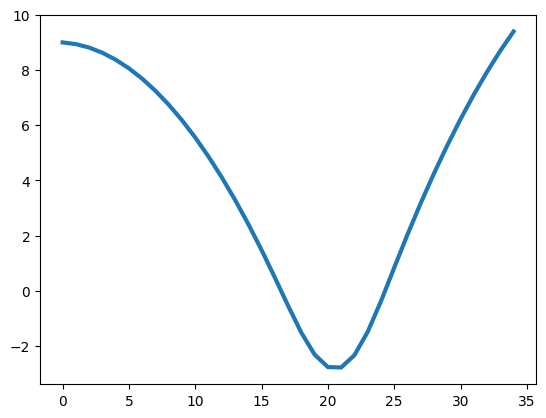

In [4]:
y_init = output_dist.gm.mean()[:35]
plt.plot(range(35), y_init, lw=3, label='SOGA w true params')

y = []
y_var = []
for i in range(35):
    y.append(output_dist.gm.mean()[output_dist.var_list.index('H['+ str(i) +']')])
    y_var.append(np.sqrt(output_dist.gm.cov()[output_dist.var_list.index('H['+ str(i) +']'), output_dist.var_list.index('H['+ str(i) +']')]))

df = pd.DataFrame({'Y_mean': y, 'Y_std': y_var})
df.to_csv('bouncing_ball_SOGA.csv', index=False)

In [73]:
program = 'normalmixtures'
soga_code = get_program(program)
#bernoulli{'_p': 0.7939}
#burglary {'_pe':0.06302589737605023,'_pb':0.132241247142518}
#clickgraph {'_p':0.6462187291480446}
#clinicaltrial {'_pe':0.05354965966247678,'_pc':0.7972821069295314, '_pt':0.778281508624521}
#murdermistery params = {'_palice':0.13767906697386637}
#surveyunbiased params = {'_bias1':0.7784414261638933,'_bias2':0.7232695283053463}
#trueskills params = {'_pa':105.98998277390048, '_pb': 89.93119031173137,'_pc':119.02132583303754}
#twocoins params = {'_first':0.3668768315529359, '_second':0.3668768315529359}
#altermu params = {'_p1':0.616792542570958,'_p2':0.616792542570958, '_p3':-3.388391756360613}
#altermu2 params = {'_muy':3.5525874090520237,'_vary':2.8375022812189092}
#normalmixtures params = {'_theta':0.717650490965452,'_p1':-4.7882963437002735, '_p2':0.6271685683915389}

params = {'_theta':0.717650490965452,'_p1':-4.7882963437002735, '_p2':0.6271685683915389}
# in soga code replace each parameter with its value
for p in params:
    soga_code = soga_code.replace(p, str(params[p]))
compiledFile = compile2SOGA_text(soga_code)
cfg = produce_cfg_text(compiledFile)
output_dist = start_SOGA(cfg)

#write in a file name of program, mean and cov
with open("output_dist_stats.txt", "a") as f:
    f.write("Program: {}\n".format(program))
    f.write("Mean: {}\n".format(output_dist.gm.mean()))
    f.write("Covariance: {}\n".format(output_dist.gm.cov()))

output_dist.gm.mean()


array([-4.78829634,  0.62716857, -3.19266153])

In [71]:

data_size = 1000
true_params, init_params, lr_param, lr_VI_param, mcmc_steps_param, mcmc_warmup_param = get_params(program)
data = generate_dataset(program, data_size, true_params)  

data_var_list = get_vars(program)
data_var_index = [output_dist.var_list.index(var) for var in data_var_list]
data = torch.tensor(data, dtype=torch.float64)


In [65]:
compute_likelihood(output_dist, data_var_list, data)

/tmp/ipykernel_26778/1211590359.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data)


tensor(-468.1291)

In [ ]:
[0.5        0.04876746 0.101084   0.10157859 0.97585744 0.25038493
 0.23656703]
[0.5        0.04876746 0.101084   0.10157859 0.97585744 0.25038493
 0.23656703]

In [43]:
soga_code = 'x = uniform([0,1],2);'
compiledFile = compile2SOGA_text(soga_code)
cfg = produce_cfg_text(compiledFile)

# computes SOGA output
output_dist = start_SOGA(cfg)
output_dist

Dist<['x'],pi: [np.float64(0.5), np.float64(0.5)] mu: [array([0.25]), array([0.75])] sigma: [array([[0.02082249]]), array([[0.02082249]])]>